In [4]:
%load_ext autoreload
%autoreload 2

from omegaconf import OmegaConf

OmegaConf.register_new_resolver(
    "relpath", lambda p: str(Path('/disk/scratch/nkudryas/BAND-torch/notebooks/').parent / p)
)

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import h5py
from sklearn.linear_model import Ridge 
from sklearn.decomposition import PCA
import os

from lfads_torch.post_run.band_analysis import run_posterior_sampling

mkdir -p failed for path /afs/inf.ed.ac.uk/user/n/nkudryas/.config/matplotlib: [Errno 13] Permission denied: '/afs/inf.ed.ac.uk/user/n/nkudryas/.config/matplotlib'
Matplotlib created a temporary cache directory at /tmp/matplotlib-sl0rctr6 because there was an issue with the default path (/afs/inf.ed.ac.uk/user/n/nkudryas/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [6]:
os.environ['TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD'] = '1'

In [69]:
PATH = '/disk/scratch/nkudryas/BAND-torch/datasets'

model_titles = ["CSAE acausal (LFADS)", "BAND acausal", "CSAE causal", "BAND causal"]

bin_size_ms = 10

In [94]:
postfix = 'forward'
dataset_name = f'lorenz_{postfix}'
model_names = ['lfads_acausal_8f_lorenz', 'band_acausal_8f_lorenz', 'lfads_both_8f_lorenz', 'band_both_8f_lorenz']
if postfix!='forward':
    model_names = [model_name+'_'+postfix for model_name in model_names]
    
best_model_dest = f"/disk/scratch/nkudryas/BAND-torch/runs/pbt-lorenz/{dataset_name}"
model_dests = [f"{best_model_dest}/{model_name}/best_model/" for model_name in model_names]
# models = [BAND(model_dir=model_dest) for model_dest in model_dests]

In [95]:
model_dests

['/disk/scratch/nkudryas/BAND-torch/runs/pbt-lorenz/lorenz_forward/lfads_acausal_8f_lorenz/best_model/',
 '/disk/scratch/nkudryas/BAND-torch/runs/pbt-lorenz/lorenz_forward/band_acausal_8f_lorenz/best_model/',
 '/disk/scratch/nkudryas/BAND-torch/runs/pbt-lorenz/lorenz_forward/lfads_both_8f_lorenz/best_model/',
 '/disk/scratch/nkudryas/BAND-torch/runs/pbt-lorenz/lorenz_forward/band_both_8f_lorenz/best_model/']

In [96]:
import torch
from hydra.utils import instantiate
from pathlib import Path
import hydra

from lfads_torch.band_utils import flatten

overrides={
        "datamodule": dataset_name,
        "model": 'lorenz'
    }
config_path="../../configs/single.yaml"
print(config_path)

# Compose the train config with properly formatted overrides
config_path = Path(config_path)
overrides = [f"{k}={v}" for k, v in flatten(overrides).items()]
with hydra.initialize(
    config_path=config_path.parent,
    job_name="get_weights",
    version_base="1.1",
):
    config = hydra.compose(config_name=config_path.name, overrides=overrides)

# Instantiate `LightningDataModule` and `LightningModule`
datamodule = instantiate(config.datamodule, _convert_="all")
model = instantiate(config.model)

# check the latest checkpoint
from glob import glob
checkpoint_folders = glob(model_dests[1]+'/checkpoint*')

ckpt_path = checkpoint_folders[-1] + '/tune.ckpt'
# f'{model_dests[1]}/lightning_checkpoints/last.ckpt'
model.load_state_dict(torch.load(ckpt_path)["state_dict"])

../../configs/single.yaml


/tmp/ipykernel_2324404/3968517386.py:35: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  model.load_state_dict(torch.load(ckpt_path)["state_dict"])


<All keys matched successfully>

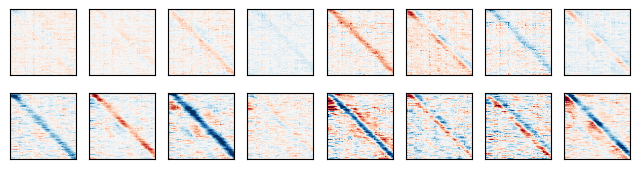

In [97]:
seq_len = config.model.recon_seq_len
in_features = config.model.fac_dim #config.model.behavior_readout.modules[0].in_features
out_features = config.model.behavior_readout.out_features
beh_W = model.behavior_readout.layers[2].weight.T

assert beh_W.shape == (in_features*seq_len, out_features*seq_len)

beh_W = beh_W.reshape((seq_len, in_features, seq_len, out_features))

r = torch.std(beh_W)*4
fig, ax = plt.subplots(out_features, in_features, figsize=(in_features, out_features))
for j in range(in_features):
    for i in range(out_features):
        ax[i,j].imshow(beh_W[:,j,:,i].detach().numpy(), cmap='RdBu', vmin=-r, vmax=r)
        ax[i,j].set_xticks([])
        ax[i,j].set_yticks([])

/tmp/ipykernel_2324404/2787394274.py:8: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  model.load_state_dict(torch.load(ckpt_path)["state_dict"])


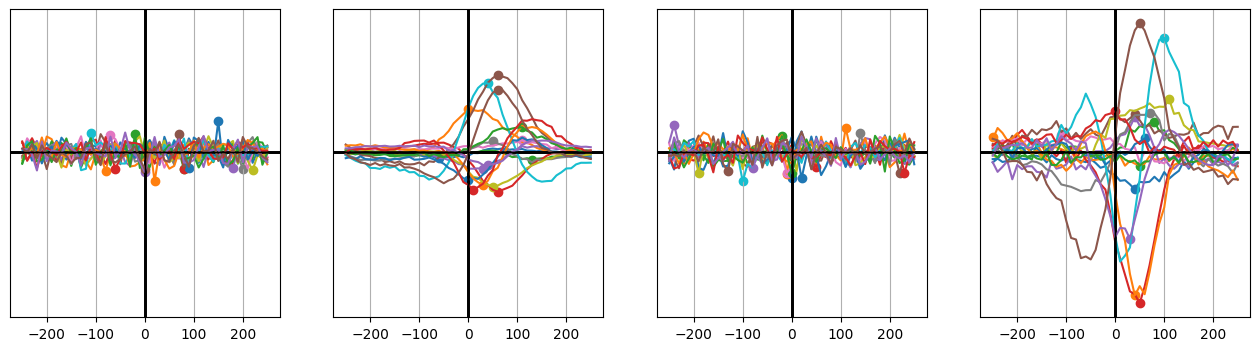

In [98]:
id_maxs = []
fig, ax = plt.subplots(1,len(model_names), figsize=(2*min(in_features,10), 2*out_features),sharey=True)
for mi, (model_name, model_dest) in enumerate(zip(model_names, model_dests)):
    # check the latest checkpoint
    from glob import glob
    checkpoint_folders = glob(model_dest+'/checkpoint*')
    ckpt_path = checkpoint_folders[-1] + '/tune.ckpt'
    model.load_state_dict(torch.load(ckpt_path)["state_dict"])

    beh_W = model.behavior_readout.layers[2].weight.T
    assert beh_W.shape == (in_features*seq_len, out_features*seq_len)
    beh_W = beh_W.reshape((seq_len, in_features, seq_len, out_features))

    for j in range(min(in_features,10)):
        for i in range(out_features):
            w = beh_W[:,j,:,i].detach().numpy()[:,:]
            lags = np.arange(-25, 26)
            amp = np.zeros_like(lags, dtype=float)
            for k,lag in enumerate(lags):
                amp[k] = np.sum(np.diag(w, k=lag))
            ax[mi].plot(10*lags,amp)
            id_max = np.argmax(np.abs(amp))
            id_maxs.append(id_max)
            ax[mi].scatter(10*lags[id_max], amp[id_max])
                
            ax[mi].axhline(0, color='k', linewidth=1)
            ax[mi].axvline(0, color='k', linewidth=1)
            ax[mi].set_yticks([])
            ax[mi].grid(True,which='both')

In [99]:
# model.eval()
# # zero out weight
# B = torch.zeros_like(model.decoder.rnn.cell.co_linear.bias)
# B[len(B) // 2:] = -10 # making variance exp(-10)
# model.decoder.rnn.cell.co_linear.weight = torch.nn.Parameter(torch.zeros_like(model.decoder.rnn.cell.co_linear.weight))
# model.decoder.rnn.cell.co_linear.bias = torch.nn.Parameter(B)

# filename = model_dests[1] + '/lfads_ablated_output.h5'
# run_posterior_sampling(model, datamodule, filename, num_samples=50)

# Evaluate perturbed vs unperturbed trials

In [100]:
dataset_filename = f'/disk/scratch/nkudryas/BAND-torch/datasets/data_Synthetic_Lorenz_{postfix}.h5'

with h5py.File(dataset_filename, 'r') as f:
    train_data = f['train_recon_data'][:]
    valid_data = f['valid_recon_data'][:]
    # train_inds, valid_inds = f["train_inds"][:], f["valid_inds"][:]
    valid_epoch = f["valid_epoch"][:]
    true_train_beh = f['train_behavior'][:]
    true_valid_beh = f['valid_behavior'][:]
    true_valid_inputs = f['valid_true_inputs'][:]
    valid_is_perturbed = np.any(np.any(true_valid_inputs != 0,axis=1),axis=1)

In [101]:
def merge_train_valid(train_data, valid_data, train_inds, valid_inds):
    n_samples = len(train_data) + len(valid_data)
    merged_data = np.full((n_samples, *train_data.shape[1:]), np.nan)
    merged_data[train_inds] = train_data
    merged_data[valid_inds] = valid_data
    return merged_data

# Get the paths to all data files
both_factors = []
both_controls = []
both_control_means = []
both_control_stds = []
both_rates = []
both_noci_rates = []
both_behaviors = []
lin_decoded_behs = []
lin_decoded_behs_abl = []
seq2seq_decoded_behs = []
seq2seq_decoded_behs_abl = []
beh_Ws_post = []
for model_name in model_names:
    data_path = os.path.join(best_model_dest,model_name,'best_model',f'lfads_output_{postfix}.h5')
    bin_width_sec = 0.01 # chewie
    # Data is binned at 10 ms
    with h5py.File(data_path) as f:
        print(f.keys())
        # Merge train and valid data for factors and rates
        # train_inds, valid_inds = f["train_inds"][:], f["valid_inds"][:]
        factors = f["valid_factors"][:]
        rates = f["valid_output_params"][:] / bin_width_sec
        controls = f['valid_gen_inputs'][:]
        ic = f['valid_gen_init'][:]
        control_mean = f['valid_co_means'][:]
        control_stds = f['valid_co_stds'][:]

        train_factors = f["train_factors"][:]
        train_controls = f['train_gen_inputs'][:]
        train_ic = f['train_gen_init'][:]

    # load ablated
    data_path = os.path.join(best_model_dest,model_name,'best_model',f'lfads_W_ablated_output_{postfix}.h5')
    with h5py.File(data_path) as f:
        train_noci_factors = f["train_factors"][:]
        noci_factors = f["valid_factors"][:]
        noci_rates = f["valid_output_params"][:] / bin_width_sec
    
    # train Ridge regression to predict behavior from factors (0lag)
    X_train = train_factors.reshape(-1,train_factors.shape[-1])
    Y_train = true_train_beh.reshape(-1,true_train_beh.shape[-1])
    X_test = factors.reshape(-1,factors.shape[-1])
    ridge = Ridge(alpha=1).fit(X_train, Y_train)
    Y_pred_0lag = ridge.predict(X_test).reshape(true_valid_beh.shape)

    X_train = train_noci_factors.reshape(-1,train_noci_factors.shape[-1])
    Y_train = true_train_beh.reshape(-1,true_train_beh.shape[-1])
    X_test = noci_factors.reshape(-1,noci_factors.shape[-1])
    ridge = Ridge(alpha=1).fit(X_train, Y_train)
    Y_pred_0lag_abl = ridge.predict(X_test).reshape(true_valid_beh.shape)

    # Ridge seq2seq
    X_train = train_factors.reshape(train_factors.shape[0],-1)
    Y_train = true_train_beh.reshape(true_train_beh.shape[0],-1)
    X_test = factors.reshape(factors.shape[0],-1)
    # X_test_abl = noci_factors.reshape(noci_factors.shape[0],-1)
    ridge = Ridge(alpha=1).fit(X_train, Y_train)
    Y_pred_seq2seq = ridge.predict(X_test).reshape(true_valid_beh.shape)
    beh_Ws_post.append(ridge.coef_)
    # Y_pred_seq2seq_abl = ridge.predict(X_test_abl).reshape(true_valid_beh.shape)

    # same after ablating the controller
    X_train = train_noci_factors.reshape(train_noci_factors.shape[0],-1)
    Y_train = true_train_beh.reshape(true_train_beh.shape[0],-1)
    X_test = noci_factors.reshape(noci_factors.shape[0],-1)
    ridge = Ridge(alpha=1).fit(X_train, Y_train)
    Y_pred_seq2seq_abl = ridge.predict(X_test).reshape(true_valid_beh.shape)
            
    both_factors.append(factors)
    both_rates.append(rates)
    both_noci_rates.append(noci_rates) 
    both_controls.append(controls)
    both_control_means.append(control_mean)
    both_control_stds.append(control_stds)
    lin_decoded_behs.append(Y_pred_0lag)
    lin_decoded_behs_abl.append(Y_pred_0lag_abl)
    seq2seq_decoded_behs.append(Y_pred_seq2seq)
    seq2seq_decoded_behs_abl.append(Y_pred_seq2seq_abl)


<KeysViewHDF5 ['params', 'train_behavior', 'train_co_means', 'train_co_stds', 'train_con_states', 'train_encod_data', 'train_epoch', 'train_factors', 'train_gen_init', 'train_gen_inputs', 'train_gen_states', 'train_ic_mean', 'train_ic_std', 'train_output_behavior_params', 'train_output_params', 'train_recon_data', 'train_true_inputs', 'train_true_latents', 'valid_behavior', 'valid_co_means', 'valid_co_stds', 'valid_con_states', 'valid_encod_data', 'valid_epoch', 'valid_factors', 'valid_gen_init', 'valid_gen_inputs', 'valid_gen_states', 'valid_ic_mean', 'valid_ic_std', 'valid_output_behavior_params', 'valid_output_params', 'valid_recon_data', 'valid_true_inputs', 'valid_true_latents']>
<KeysViewHDF5 ['params', 'train_behavior', 'train_co_means', 'train_co_stds', 'train_con_states', 'train_encod_data', 'train_epoch', 'train_factors', 'train_gen_init', 'train_gen_inputs', 'train_gen_states', 'train_ic_mean', 'train_ic_std', 'train_output_behavior_params', 'train_output_params', 'train_rec

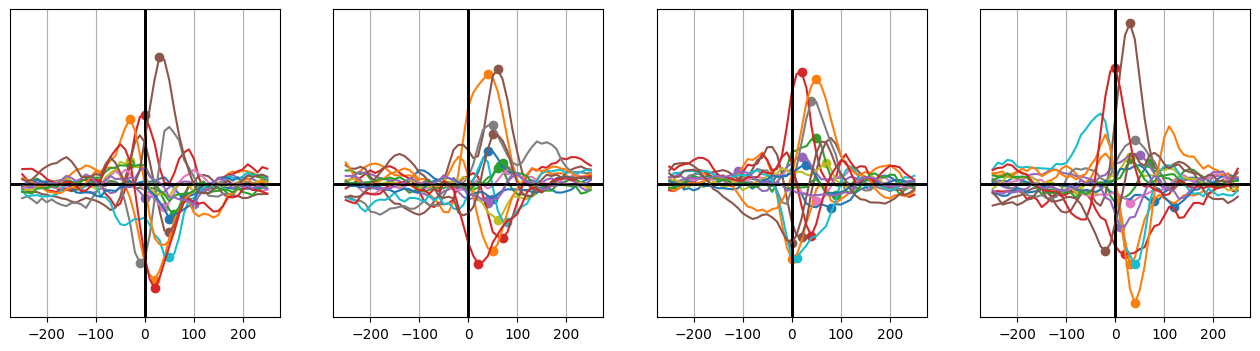

In [102]:
id_maxs = []
fig, ax = plt.subplots(1,len(model_names), figsize=(2*min(in_features,10), 2*out_features),sharey=True)
for mi, (model_name, model_dest) in enumerate(zip(model_names, model_dests)):
    beh_W = beh_Ws_post[mi].T
    assert beh_W.shape == (in_features*seq_len, out_features*seq_len)
    beh_W = beh_W.reshape((seq_len, in_features, seq_len, out_features))
    for j in range(min(in_features,10)):
        for i in range(out_features):
            w = beh_W[:,j,:,i]
            lags = np.arange(-25, 26)
            amp = np.zeros_like(lags, dtype=float)
            for k,lag in enumerate(lags):
                amp[k] = np.sum(np.diag(w, k=lag))
            ax[mi].plot(10*lags,amp)
            id_max = np.argmax(np.abs(amp))
            id_maxs.append(id_max)
            ax[mi].scatter(10*lags[id_max], amp[id_max])
                
            ax[mi].axhline(0, color='k', linewidth=1)
            ax[mi].axvline(0, color='k', linewidth=1)
            ax[mi].set_yticks([])
            ax[mi].grid(True,which='both')

lfads_acausal_8f_lorenz:   2.33+-  1.27
band_acausal_8f_lorenz:   5.05+-  1.51
lfads_both_8f_lorenz:   2.16+-  2.08
band_both_8f_lorenz:   3.09+-  1.04


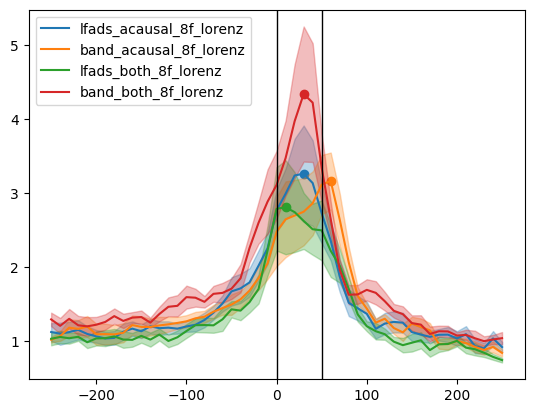

In [103]:
id_maxs = []
for mi, (model_name, model_dest) in enumerate(zip(model_names, model_dests)):
    beh_W = beh_Ws_post[mi].T
    assert beh_W.shape == (in_features*seq_len, out_features*seq_len)
    beh_W = beh_W.reshape((seq_len, in_features, seq_len, out_features))

    # bootstrap on factors
    amps = []
    for _ in range(100):
        resample_factors = np.random.choice(in_features, size=in_features, replace=True)
        w = (beh_W[:,resample_factors]**2).sum(-1).sum(1)
        lags = np.arange(-25, 26)
        amp = np.zeros_like(lags, dtype=float)
        for k,lag in enumerate(lags):
            amp[k] = np.sum(np.diag(w, k=lag))
        amps.append(amp)
    amps = np.array(amps)
    plt.plot(10*lags,amps.mean(0),label=model_name,c=f'C{mi}')
    plt.fill_between(10*lags, amps.mean(0)-amps.std(0), amps.mean(0)+amps.std(0), alpha=0.3,color=f'C{mi}')
    id_max = np.argmax(np.abs(amps.mean(0)))
    id_maxs.append(id_max)
    plt.scatter(10*lags[id_max], amps.mean(0)[id_max])
    distr_args = np.argmax(amps,axis=-1)
    print(f"{model_name}: {distr_args.mean()-25:6.2f}+-{distr_args.std():6.2f}")
plt.legend()
plt.axvline(0,c='k',linewidth=1)
plt.axvline(50,c='k',linewidth=1)

Text(0.5, 1.0, 'Behavior decoding R2 from factors: Ablated vs Non-ablated')

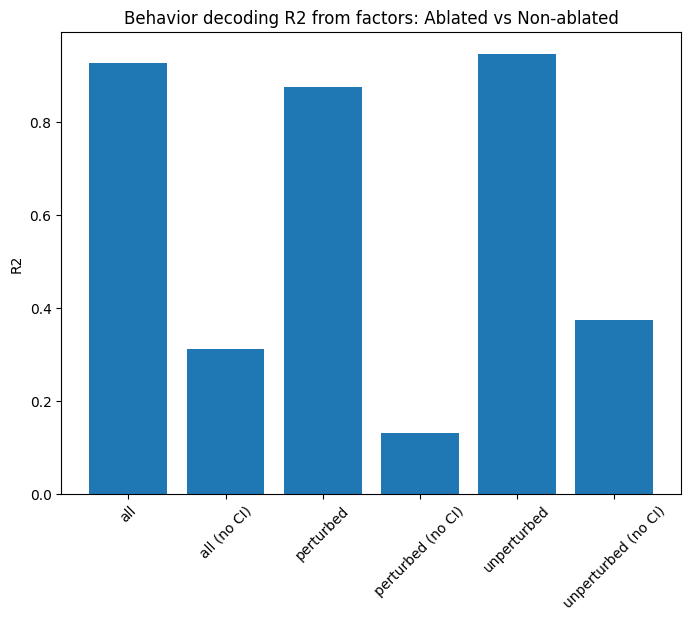

In [44]:
# compute behavior seq2seq R2 for perturbed vs unperturbed trials, ablated vs non-ablated; plot a bar plot
# valid_set['is_perturbed']
from lfads_torch.metrics import r2_score
plt.figure(figsize=(8,6))

model_id = 0 # 0 -- LFADS, 1 -- BAND
Y_pred, Y_pred_abl = seq2seq_decoded_behs[model_id], seq2seq_decoded_behs_abl[model_id]
# Y_pred, Y_pred_abl = lin_decoded_behs[model_id], lin_decoded_behs_abl[model_id]
plt.bar(['all', 'all (no CI)','perturbed','perturbed (no CI)', 'unperturbed', 'unperturbed (no CI)'], 
        
                                            [r2_score(true_valid_beh, Y_pred_seq2seq), 
                                                        r2_score(true_valid_beh, Y_pred_abl),
                                            r2_score(true_valid_beh[valid_is_perturbed], 
                                                     Y_pred[valid_is_perturbed]), 
                                            r2_score(true_valid_beh[valid_is_perturbed], 
                                                     Y_pred_abl[valid_is_perturbed]),
                                            r2_score(true_valid_beh[~valid_is_perturbed], 
                                                     Y_pred[~valid_is_perturbed]), 
                                            r2_score(true_valid_beh[~valid_is_perturbed], 
                                                     Y_pred_abl[~valid_is_perturbed])])
# rotate labels by 45 degrees
plt.xticks(rotation=45)
plt.ylabel('R2')
plt.title('Behavior decoding R2 from factors: Ablated vs Non-ablated')

Text(0.5, 1.0, 'BPS: Ablated vs Non-ablated')

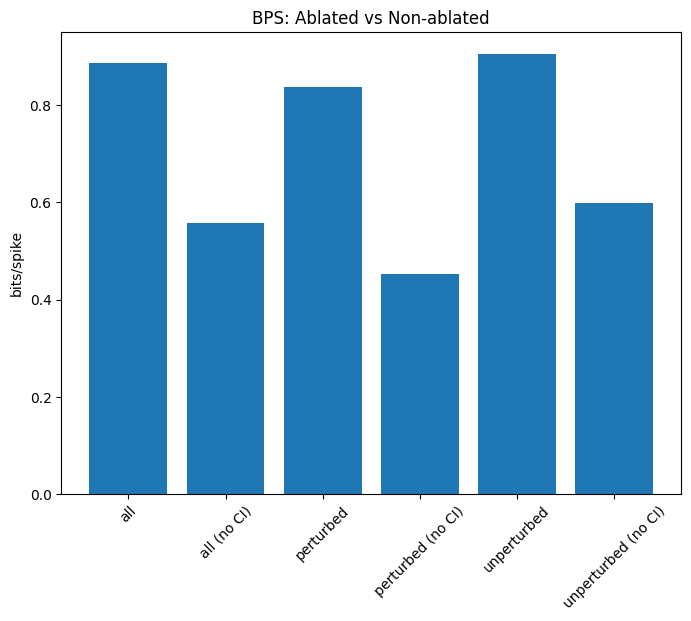

In [46]:
# now same but for NLL
from scipy.stats import poisson
plt.figure(figsize=(8,6))
model_id = 3 # 0 -- LFADS, 1 -- BAND
rates, noci_rates = both_rates[model_id] * bin_width_sec, both_noci_rates[model_id] * bin_width_sec

valid_mean_count = valid_data.mean(0).mean(0) # to get Hz -> x100
base_LL = poisson.logpmf(valid_data, valid_mean_count)
n_sp = valid_data.sum()
# print(base_LL.mean(),poisson.logpmf(valid_data, rates).mean())
# print(np.nansum(poisson.logpmf(valid_data, rates) - base_LL)/(n_sp * np.log(2)))

plt.bar(['all', 'all (no CI)','perturbed','perturbed (no CI)', 'unperturbed', 'unperturbed (no CI)'],
        [np.nansum(poisson.logpmf(valid_data, rates) - base_LL)/(n_sp * np.log(2)),
                np.nansum(poisson.logpmf(valid_data, noci_rates) - base_LL)/(n_sp * np.log(2)),
                np.nansum(poisson.logpmf(valid_data[valid_is_perturbed], rates[valid_is_perturbed]) - base_LL[valid_is_perturbed])/(valid_data[valid_is_perturbed].sum() * np.log(2)),
                np.nansum(poisson.logpmf(valid_data[valid_is_perturbed], noci_rates[valid_is_perturbed]) - base_LL[valid_is_perturbed])/(valid_data[valid_is_perturbed].sum() * np.log(2)),
                np.nansum(poisson.logpmf(valid_data[~valid_is_perturbed], rates[~valid_is_perturbed]) - base_LL[~valid_is_perturbed])/(valid_data[~valid_is_perturbed].sum() * np.log(2)),
                np.nansum(poisson.logpmf(valid_data[~valid_is_perturbed], noci_rates[~valid_is_perturbed]) - base_LL[~valid_is_perturbed])/(valid_data[~valid_is_perturbed].sum() * np.log(2))])
plt.xticks(rotation=45)
plt.ylabel('bits/spike')
plt.title('BPS: Ablated vs Non-ablated')

# Run on test

In [53]:
# config.datamodule.datafile_pattern = config.datamodule.datafile_pattern.split('.h5')[0] + '_test.h5'
# config.model.ic_enc_seq_len = 0
# config.model.causal_con = False
# datamodule_test = instantiate(config.datamodule, _convert_="all")

# for md,mn in zip(model_dests,model_names):
#     model = instantiate(config.model)
#     # check the latest checkpoint
#     checkpoint_folders = glob(md+'/checkpoint*')

#     ckpt_path = checkpoint_folders[-1] + '/tune.ckpt'
#     # f'{model_dests[1]}/lightning_checkpoints/last.ckpt'
#     model.load_state_dict(torch.load(ckpt_path)["state_dict"])
   
#     filename = md + f'/{mn}_test_adaptation.h5'
#     run_posterior_sampling(model, datamodule_test, filename, num_samples=50)

# Evaluate results on test

In [ ]:
dataset_filename = '/disk/scratch/nkudryas/BAND-torch/datasets/data_Synthetic_Lorenz_Offmanifold_Unidir_Kicks.h5'

with h5py.File(dataset_filename, 'r') as f:
    train_data = f['train_recon_data'][:]
    valid_data = f['valid_recon_data'][:]
    # train_inds, valid_inds = f["train_inds"][:], f["valid_inds"][:]
    valid_epoch = f["valid_epoch"][:]
    true_train_beh = f['train_behavior'][:]
    true_valid_beh = f['valid_behavior'][:]
    # true_target_direction = f['valid_target_direction'][:]

# train_set = torch.load("/disk/scratch/nkudryas/Xfads_with_Inferred_Inputs/DATA/data_Synthetic_Lorenz_Offmanifold_Unidir_Kicks/data_train_20ms.pt")
test_set = torch.load("/disk/scratch/nkudryas/Xfads_with_Inferred_Inputs/DATA/data_Synthetic_Lorenz_Offmanifold_Unidir_Kicks/data_test_adaptation_20ms.pt")

/tmp/ipykernel_694926/846874805.py:13: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  valid_set = torch.load("/disk/scratch/nkudryas/Xfads_with_Inferred_Inputs/DATA/data_Synthetic_Lorenz_Offmanifold_Unidir_Kicks/data_valid_20ms.pt")
/tmp/ipykernel_694926/846874805.py:14: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  test_set = torch.load("/disk/scratch/nkudryas/Xfads_with_Inferred_Inputs/DATA/data_Synthetic_Lorenz_Offmanifold_Unidir_Kicks/data_test_adaptation_20ms.pt")


In [ ]:
def merge_train_valid(train_data, valid_data, train_inds, valid_inds):
    n_samples = len(train_data) + len(valid_data)
    merged_data = np.full((n_samples, *train_data.shape[1:]), np.nan)
    merged_data[train_inds] = train_data
    merged_data[valid_inds] = valid_data
    return merged_data

# Get the paths to all data files
both_factors = []
both_controls = []
both_control_means = []
both_control_stds = []
both_rates = []
both_ics = []
both_behaviors = []
lin_decoded_behs = []
seq2seq_decoded_behs = []
control_decoded_behs = []
ridge_models_0_lag = []
for model_name in model_names:
    # if 'band' in model_name:
    #     data_path = os.path.join(best_model_dest,model_name,'best_model','lfads_ablated_output_sess0.h5')
    # else:
    # data_path = os.path.join(best_model_dest,model_name,'best_model','lfads_output_Kicks.h5')
    data_path = f'{model_name}_test_adaptation_test.h5'
    bin_width_sec = 0.01 # chewie
    # Data is binned at 10 ms
    with h5py.File(data_path) as f:
        print(f.keys())
        # Merge train and valid data for factors and rates
        # train_inds, valid_inds = f["train_inds"][:], f["valid_inds"][:]
        factors = f["valid_factors"][:]
        rates = f["valid_output_params"][:] / bin_width_sec
        behavior = f["valid_output_behavior_params"][:]
        controls = f['valid_gen_inputs'][:]
        ic = f['valid_gen_init'][:]
        control_mean = f['valid_co_means'][:]
        control_stds = f['valid_co_stds'][:]

        train_factors = f["train_factors"][:]
        train_controls = f['train_gen_inputs'][:]
        train_ic = f['train_gen_init'][:]

    # # load ablated
    # data_path = os.path.join(best_model_dest,model_name,'best_model','lfads_ablated_output_sess0.h5')
    # with h5py.File(data_path) as f:
    #     noci_factors = f["valid_factors"][:]
        
    
    # train Ridge regression to predict behavior from factors (0lag)
    X_train = train_factors.reshape(-1,train_factors.shape[-1])
    Y_train = true_train_beh.reshape(-1,true_train_beh.shape[-1])
    X_test = factors.reshape(-1,factors.shape[-1])
    ridge = Ridge(alpha=1).fit(X_train, Y_train)
    Y_pred_0lag = ridge.predict(X_test).reshape(true_valid_beh.shape)
    ridge_models_0_lag.append(ridge)

    # Ridge seq2seq
    X_train = train_factors.reshape(train_factors.shape[0],-1)
    Y_train = true_train_beh.reshape(true_train_beh.shape[0],-1)
    X_test = factors.reshape(factors.shape[0],-1)
    ridge = Ridge(alpha=1).fit(X_train, Y_train)
    Y_pred_seq2seq = ridge.predict(X_test).reshape(true_valid_beh.shape)

    # Ridge from control inputs (seq2seq)
    X_train = train_controls.reshape(train_controls.shape[0],-1)
    Y_train = true_train_beh.reshape(true_train_beh.shape[0],-1)
    X_test = controls.reshape(controls.shape[0],-1)
    ridge = Ridge(alpha=1).fit(X_train, Y_train)
    Y_pred_control = ridge.predict(X_test).reshape(true_valid_beh.shape)

    # Ridge decode residuals

            
    both_factors.append(factors)
    both_controls.append(controls)
    both_control_means.append(control_mean)
    both_control_stds.append(control_stds)
    both_rates.append(rates)
    both_behaviors.append(behavior)
    lin_decoded_behs.append(Y_pred_0lag)
    seq2seq_decoded_behs.append(Y_pred_seq2seq)
    control_decoded_behs.append(Y_pred_control)

<KeysViewHDF5 ['train_behavior', 'train_co_means', 'train_co_stds', 'train_con_states', 'train_encod_data', 'train_epoch', 'train_factors', 'train_gen_init', 'train_gen_inputs', 'train_gen_states', 'train_ic_mean', 'train_ic_std', 'train_output_behavior_params', 'train_output_params', 'train_recon_data', 'valid_behavior', 'valid_co_means', 'valid_co_stds', 'valid_con_states', 'valid_encod_data', 'valid_epoch', 'valid_factors', 'valid_gen_init', 'valid_gen_inputs', 'valid_gen_states', 'valid_ic_mean', 'valid_ic_std', 'valid_output_behavior_params', 'valid_output_params', 'valid_recon_data']>
(1600, 200) (400, 2)
<KeysViewHDF5 ['train_behavior', 'train_co_means', 'train_co_stds', 'train_con_states', 'train_encod_data', 'train_epoch', 'train_factors', 'train_gen_init', 'train_gen_inputs', 'train_gen_states', 'train_ic_mean', 'train_ic_std', 'train_output_behavior_params', 'train_output_params', 'train_recon_data', 'valid_behavior', 'valid_co_means', 'valid_co_stds', 'valid_con_states', 'v

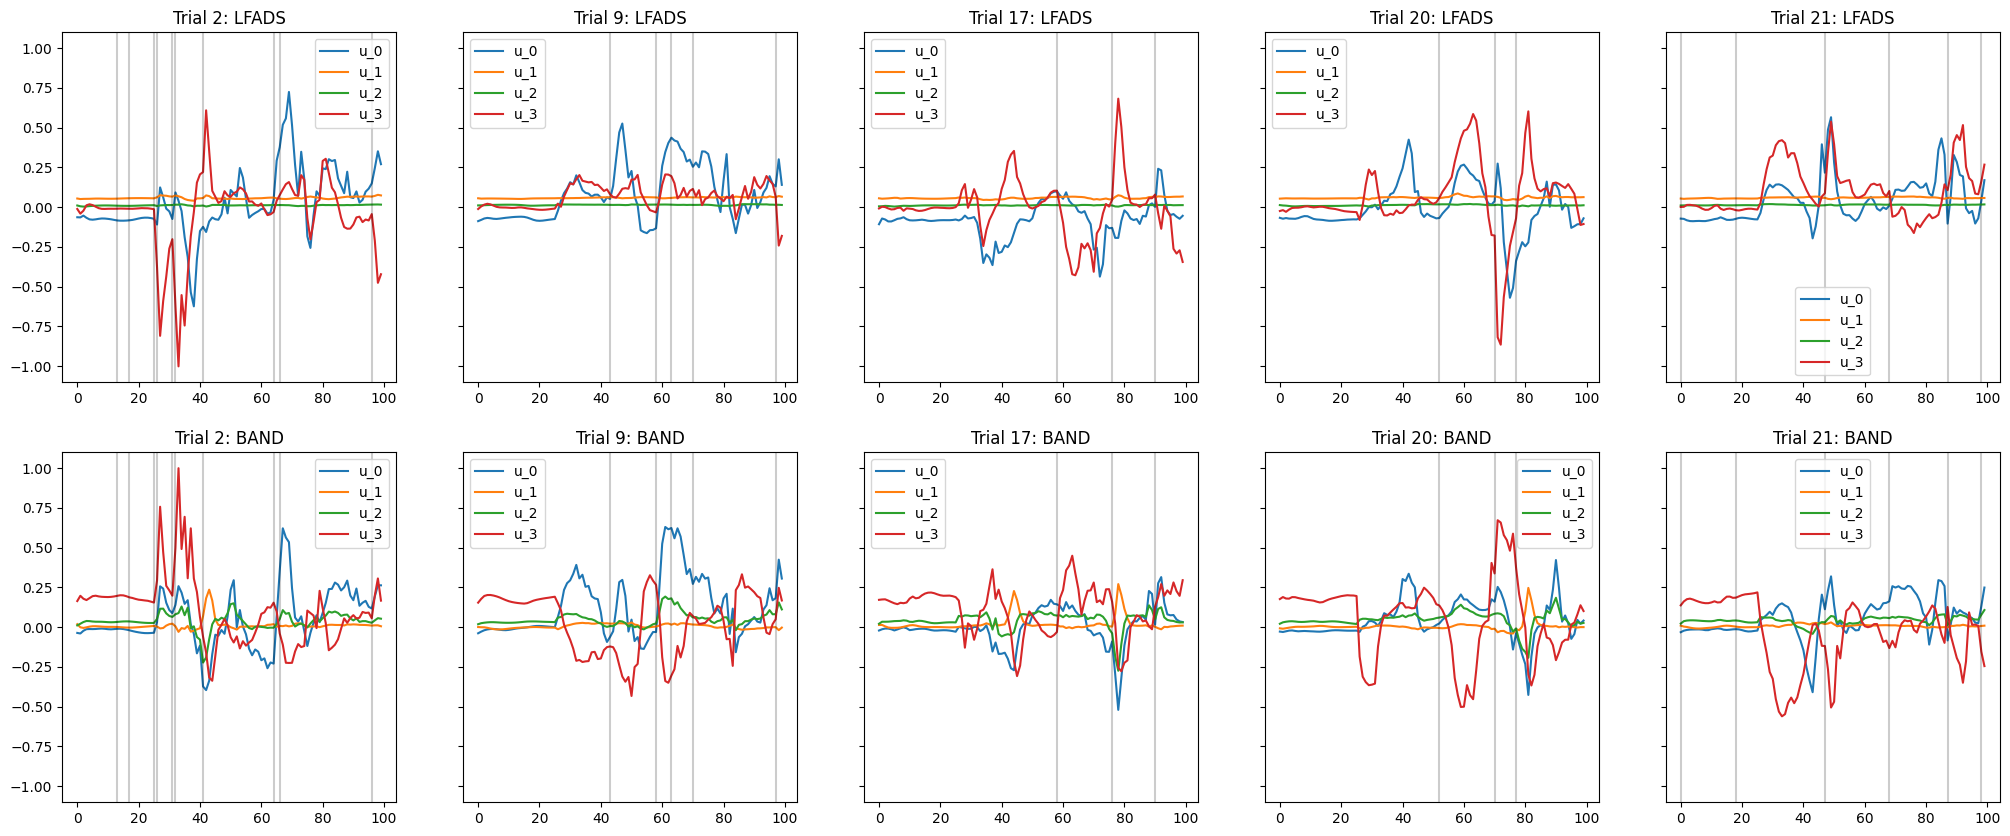

In [57]:
co_dim = both_controls[0].shape[-1]
trials2plot=[2,9,17,20,21]
trial_num=len(trials2plot)
fig, axes = plt.subplots(2, trial_num, figsize=(5*trial_num,10),sharey=True)
for it, t in enumerate(trials2plot):
    for i, model_name in enumerate(model_names):
        for j in range(co_dim):
            axes[i,it].plot(both_control_means[i][t,:,j], label=f'u_{j}')
            axes[i,it].set_title(f'Trial {t}: {model_name.split("_")[0].upper()}')
            axes[i,it].legend()
        for l in test_set['kick_bins'][t]:
            axes[i,it].axvline(l,c='k',alpha=0.2)

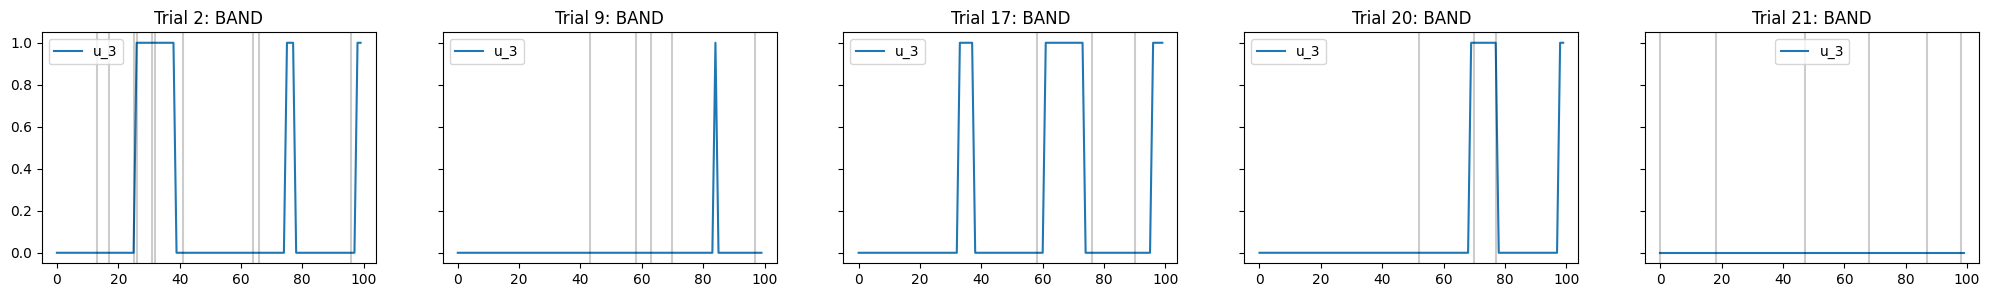

In [58]:
# apply k-means with k=2
flat_controls = both_control_means[0].reshape(-1, both_control_means[0].shape[-1])
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, random_state=0).fit(flat_controls)
labels = kmeans.labels_.reshape(both_control_means[0].shape[0], both_control_means[0].shape[1])

co_dim = both_control_means[0].shape[-1]
trials2plot=[2,9,17,20,21]
trial_num=len(trials2plot)
fig, axes = plt.subplots(1, trial_num, figsize=(5*trial_num,3),sharey=True)
for it, t in enumerate(trials2plot):
    axes[it].plot(labels[t,:], label=f'u_{j}')
    axes[it].set_title(f'Trial {t}: {model_name.split("_")[0].upper()}')
    axes[it].legend()
    for l in test_set['kick_bins'][t]:
        axes[it].axvline(l,c='k',alpha=0.2)

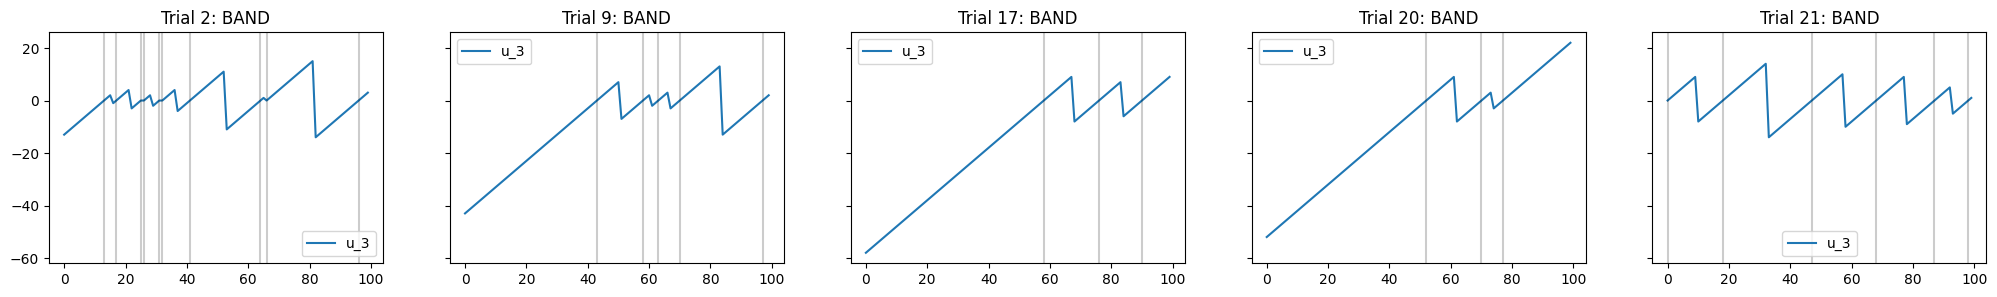

In [59]:
# create a variable that tracks distance to nearest kick
distances = np.zeros((both_control_means[0].shape[0], both_control_means[0].shape[1]))
for t in range(both_control_means[0].shape[0]):
    for i in range(both_control_means[0].shape[1]):
        kick_times = test_set['kick_bins'][t]
        if len(kick_times) > 0:
            arg = np.argmin(np.abs(np.array(kick_times) - i))
            distances[t,i] = i-np.array(kick_times)[arg]
        else:
            distances[t,i] = np.inf

fig, axes = plt.subplots(1, trial_num, figsize=(5*trial_num,3),sharey=True)
for it, t in enumerate(trials2plot):
    axes[it].plot(distances[t,:], label=f'u_{j}')
    axes[it].set_title(f'Trial {t}: {model_name.split("_")[0].upper()}')
    axes[it].legend()
    for l in test_set['kick_bins'][t]:
        axes[it].axvline(l,c='k',alpha=0.2)

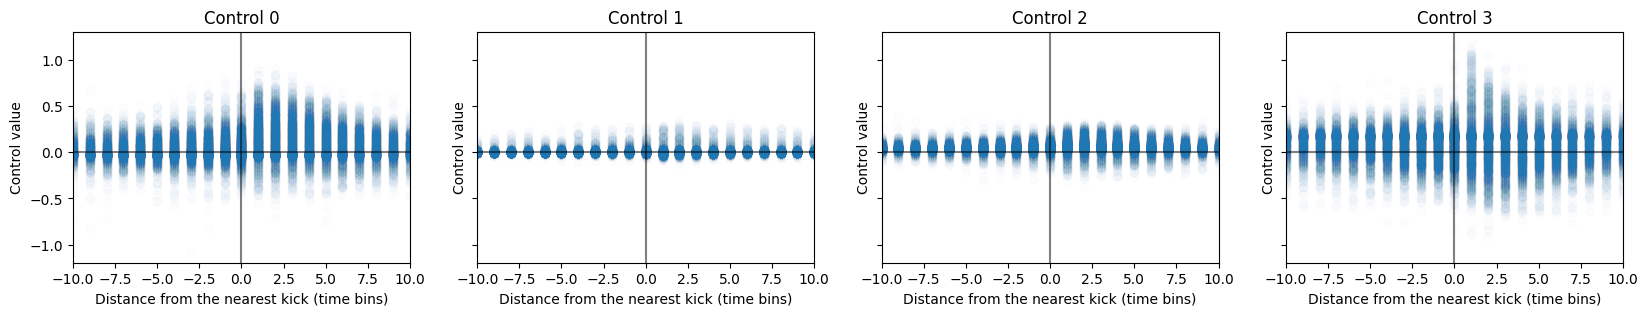

In [62]:
# plot control wrt distance to kick
fig, axes = plt.subplots(1, co_dim, figsize=(5*co_dim,3),sharey=True) 
for c in range(co_dim):
    axes[c].plot(distances.flatten(), both_control_means[1][...,c].flatten(), 'o', alpha=0.01)
    axes[c].set_title(f'Control {c}')
    axes[c].set_xlabel('Distance from the nearest kick (time bins)')
    axes[c].set_ylabel('Control value')
    axes[c].axvline(0,c='k',alpha=0.5)
    axes[c].axhline(0,c='k',alpha=0.5)
    axes[c].set_xlim(-10,10)

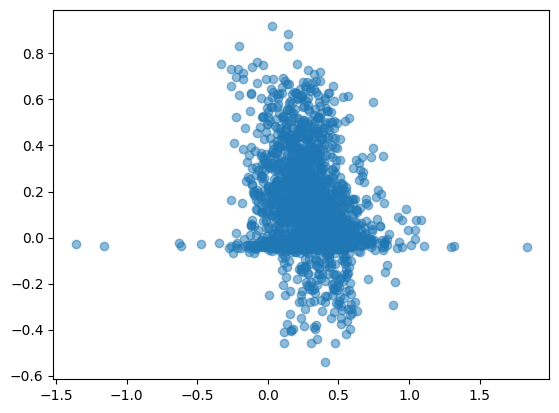

In [85]:
# collect all true state changes around kicks, correlate with control inputs 1 step after the kick
# test_set['true_latents']
state_changes = []
control_inputs = []
for trial in range(test_set['true_latents'].shape[0]):
    # trial_state_changes = []
    # trial_control_inputs = []
    kick_bins = test_set['kick_bins'][trial]
    for kick in kick_bins:
        if kick < test_set['true_latents'].shape[1]-1: # ensure we have a time point after the kick
            state_change = test_set['true_latents'][trial, kick+1] - test_set['true_latents'][trial, kick-1]  
            control_input = both_control_means[1][trial, kick+1]
            state_changes.append(state_change)
            control_inputs.append(control_input)

plt.scatter(np.array(state_changes)[:,0], np.array(control_inputs)[:,0], alpha=0.5)



In [67]:
# learn to classify control inputs 1 bin after the true kick from 1 bin before; apply to all data, compute F-score for false positives
controls_1_bin_after = []
controls_1_bin_before = []
for trial in range(both_control_means[0].shape[0]):
    kick_bins = test_set['kick_bins'][trial]
    for kick in kick_bins:
        if kick > 0 and kick < both_control_means[0].shape[1]-1:
            controls_1_bin_after.append(both_control_means[1][trial,kick+1])
            controls_1_bin_before.append(both_control_means[1][trial,kick-1])

from sklearn.linear_model import LogisticRegression

X = np.concatenate([controls_1_bin_after, controls_1_bin_before])
y = np.concatenate([np.ones(len(controls_1_bin_after)), np.zeros(len(controls_1_bin_before))])
X_test = both_control_means[1].reshape(-1, both_control_means[1].shape[-1])
y_test = np.zeros(X_test.shape[0])
for trial in range(both_control_means[0].shape[0]):
    kick_bins = test_set['kick_bins'][trial]
    for kick in kick_bins:
        if kick > 0 and kick < both_control_means[0].shape[1]-1:
            idx = trial*both_control_means[0].shape[1] + kick
            y_test[idx] = 1
clf = LogisticRegression().fit(X, y)
y_pred = clf.predict(X_test)


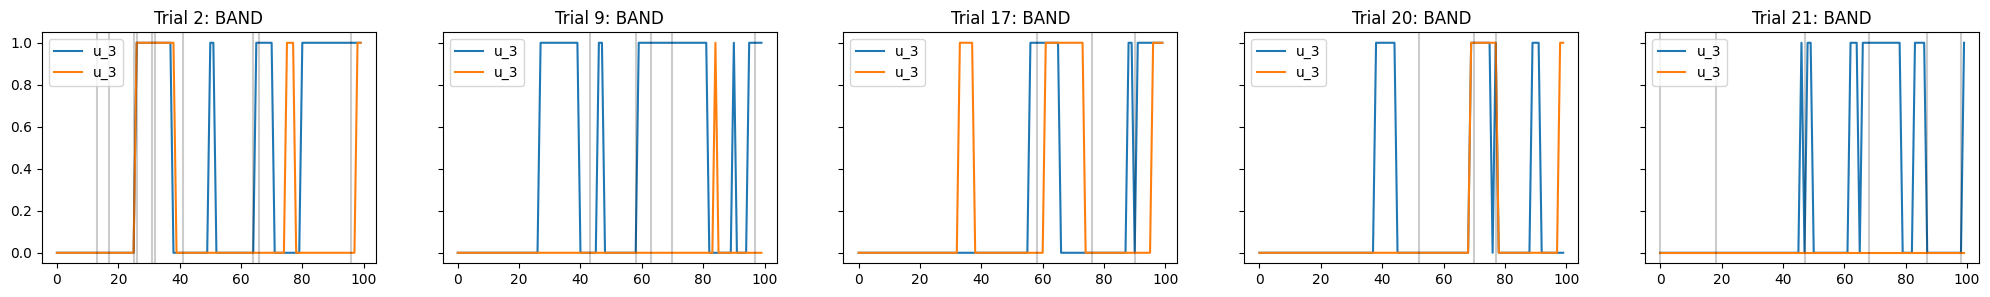

In [ ]:
fig, axes = plt.subplots(1, trial_num, figsize=(5*trial_num,3),sharey=True)
for it, t in enumerate(trials2plot):
    axes[it].plot(y_pred.reshape(both_control_means[1].shape[:2])[t,:], label=f'u_{j}')
    axes[it].set_title(f'Trial {t}: {model_name.split("_")[0].upper()}')
    axes[it].legend()
    for l in test_set['kick_bins'][t]:
        axes[it].axvline(l,c='k',alpha=0.2)

(array([ 544.,  631.,  711.,  763.,  859.,  939., 1038., 1112., 1231.,
        1358., 1498.,  964.,  875.,  791.,  757.,  732.,  707.,  675.,
         639.,  607.,  557.]),
 array([-10.5,  -9.5,  -8.5,  -7.5,  -6.5,  -5.5,  -4.5,  -3.5,  -2.5,
         -1.5,  -0.5,   0.5,   1.5,   2.5,   3.5,   4.5,   5.5,   6.5,
          7.5,   8.5,   9.5,  10.5]),
 <BarContainer object of 21 artists>)

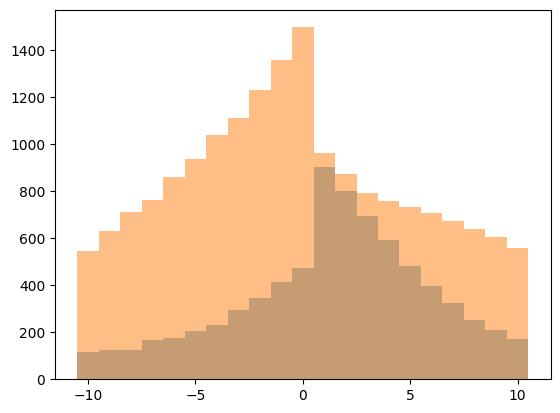

In [70]:
# plot prediction wrt distance to kick
# plt.plot(distances.flatten(), y_pred, 'o', alpha=0.01)
plt.hist(distances.flatten()[y_pred==1], bins=np.arange(-10.5,11.5,1), alpha=0.5, label='Predicted Kick')
plt.hist(distances.flatten()[y_pred==0], bins=np.arange(-10.5,11.5,1), alpha=0.5, label='Predicted No Kick')

In [17]:
# save latents and controls in lfads and band files
for i, model_name in enumerate(model_names):
    save_path = f"./{dataset_name}_{model_name}_latents_controls.h5"
    with h5py.File(save_path, 'w') as f:
        f.create_dataset('factors', data=both_factors[i])
        f.create_dataset('controls', data=both_controls[i])
        f.create_dataset('control_means', data=both_control_means[i])
        f.create_dataset('control_stds', data=both_control_stds[i])
        f.create_dataset('rates', data=both_rates[i])
        f.create_dataset('ics_pca', data=both_ics[i])
        f.create_dataset('behaviors', data=both_behaviors[i])
        f.create_dataset('lin_decoded_behaviors', data=lin_decoded_behs[i])
        f.create_dataset('seq2seq_decoded_behaviors', data=seq2seq_decoded_behs[i])
        f.create_dataset('control_decoded_behaviors', data=control_decoded_behs[i])

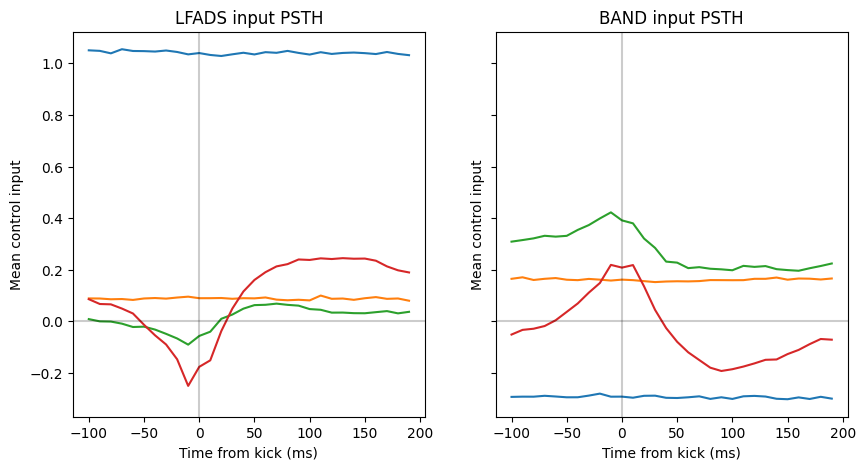

In [18]:
# compute PSTHs
t_before, t_after = 10, 20
data_set = test_set
both_PSTHs = [np.zeros((co_dim, t_before + t_after)) for _ in model_names]
for i, model_name in enumerate(model_names):
    for t in range(len(data_set['kick_bins'])):
        for l in data_set['kick_bins'][t]:
            if l-t_before >= 0 and l+t_after < both_controls[i].shape[1]:
                both_PSTHs[i] += both_controls[i][t,l-t_before:l+t_after,:].T
    both_PSTHs[i] /= float(len(data_set['kick_bins']))

fig, ax = plt.subplots(1,2,figsize=(10,5),sharey=True)
time_axis = np.arange(-t_before, t_after) * 0.01 * 1000
for i, model_name in enumerate(model_names):
    ax[i].plot(time_axis, both_PSTHs[i].T)
    ax[i].set_title(f'{model_name.split("_")[0].upper()} input PSTH')
    ax[i].set_xlabel('Time from kick (ms)')
    ax[i].set_ylabel('Mean control input')
    ax[i].axvline(0,c='k',alpha=0.2)
    ax[i].axhline(0,c='k',alpha=0.2)

